In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/RELIANCE.NS_.csv")

In [ ]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-07-21,507.192322,507.687622,497.781525,498.450195,485.688568,3097170.0
1,2016-07-22,498.276825,504.121429,497.831055,502.660278,489.790863,3184126.0
2,2016-07-25,502.239258,507.068512,498.945496,506.573181,493.603546,3803482.0
3,2016-07-26,506.697021,512.541626,502.833649,507.217102,494.231049,4853316.0
4,2016-07-27,506.721771,508.182922,499.737976,501.793488,488.946259,5090697.0
...,...,...,...,...,...,...,...
1229,2021-07-14,2100.350098,2106.850098,2081.250000,2086.000000,2086.000000,3937768.0
1230,2021-07-15,2095.000000,2095.000000,2078.500000,2082.350098,2082.350098,4360415.0
1231,2021-07-16,2087.750000,2114.750000,2087.600098,2112.399902,2112.399902,4074206.0
1232,2021-07-19,2100.000000,2124.000000,2092.250000,2098.949951,2098.949951,3855577.0


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/RELIANCE.NS_.csv')

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort values by date
df = df.sort_values('Date')

# Set Date as index
df.set_index('Date', inplace=True)

# Handle missing values
df.fillna(method='ffill', inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Convert columns to numeric if needed
cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Drop remaining null values
df.dropna(inplace=True)

print("Data Cleaned Successfully ✅")
print(df.head())

Data Cleaned Successfully ✅
                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2016-07-21  507.192322  507.687622  497.781525  498.450195  485.688568   
2016-07-22  498.276825  504.121429  497.831055  502.660278  489.790863   
2016-07-25  502.239258  507.068512  498.945496  506.573181  493.603546   
2016-07-26  506.697021  512.541626  502.833649  507.217102  494.231049   
2016-07-27  506.721771  508.182922  499.737976  501.793488  488.946259   

               Volume  
Date                   
2016-07-21  3097170.0  
2016-07-22  3184126.0  
2016-07-25  3803482.0  
2016-07-26  4853316.0  
2016-07-27  5090697.0  


/tmp/ipykernel_6220/2799952462.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare 'Month' and 'Year' columns
df['Month'] = df.index.month_name()
df['Year'] = df.index.year

# Calculate Daily Return
df['Daily Return'] = df['Close'].pct_change() * 100

# Calculate Moving Averages
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Calculate Volatility
df['Volatility'] = df['Daily Return'].rolling(window=30).std()

# Calculate Intraday Change
df['Intraday Change'] = df['Close'] - df['Open']

# Calculate Daily Range
df['Daily Range'] = df['High'] - df['Low']

print("All necessary columns for insights created.")

All necessary columns for insights created.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare 'Month' and 'Year' columns
df['Month'] = df.index.month_name()
df['Year'] = df.index.year

# Calculate Daily Return
df['Daily Return'] = df['Close'].pct_change() * 100

# Calculate Moving Averages
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Calculate Volatility
df['Volatility'] = df['Daily Return'].rolling(window=30).std()

# Calculate Intraday Change
df['Intraday Change'] = df['Close'] - df['Open']

# Calculate Daily Range
df['Daily Range'] = df['High'] - df['Low']

print("All necessary columns for insights created.")

All necessary columns for insights created.


### Insight 1: Overall Stock Price Trend

**Description:** This insight shows the general movement of the stock's closing price over the entire period.

**Why this graph (Line Plot)?** A line plot is the most suitable choice for visualizing time-series data like stock prices. It clearly illustrates the continuous change and trend over time, making it easy to identify upward or downward movements.

**Purpose:** To provide a high-level overview of the stock's performance, identify long-term trends, and see periods of significant growth or decline.

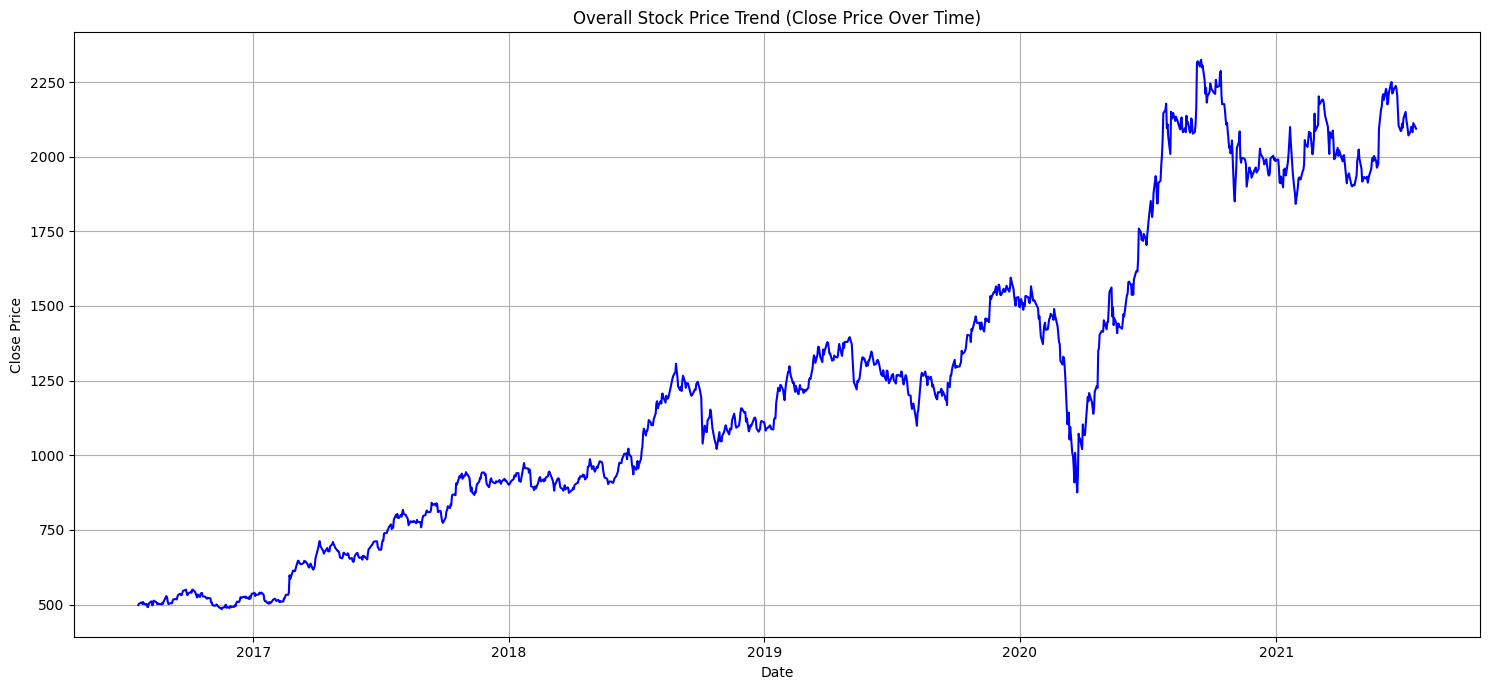

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(x=df.index, y='Close', data=df, color='blue')
plt.title('Overall Stock Price Trend (Close Price Over Time)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()

### Insight 2: Distribution of Intraday Price Changes

**Description:** This insight examines the distribution of the difference between the closing price and opening price on a given day. A positive value means the stock closed higher than it opened, and a negative value means it closed lower.

**Why this graph (Histogram)?** A histogram is ideal for displaying the distribution of a single numerical variable. It shows the frequency of different intraday change values, helping to understand typical daily movements and identify any skewed patterns.

**Purpose:** To understand the common magnitude and direction of daily price changes within the trading day, indicating if the stock typically gains or loses value from open to close.

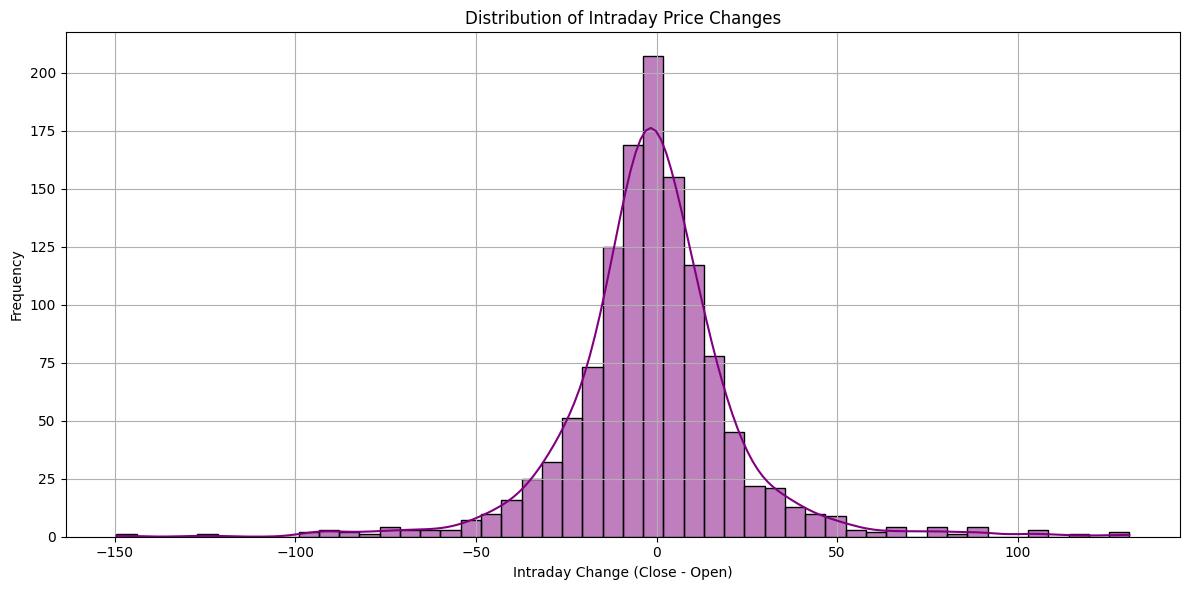

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Intraday Change'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Intraday Price Changes')
plt.xlabel('Intraday Change (Close - Open)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

### Insight 3: Trading Volume Over Time

**Description:** This insight visualizes the total number of shares traded each day, indicating market activity and liquidity.

**Why this graph (Area Plot)?** An area plot is effective for showing trends in quantitative data over time, similar to a line plot, but it fills the area beneath the line, which can visually emphasize the magnitude of the volume more effectively than a simple line. It's good for illustrating the overall 'mass' of activity.

**Purpose:** To identify periods of high or low trading interest, which can correspond to significant news, events, or price movements. Higher volume often confirms price trends.

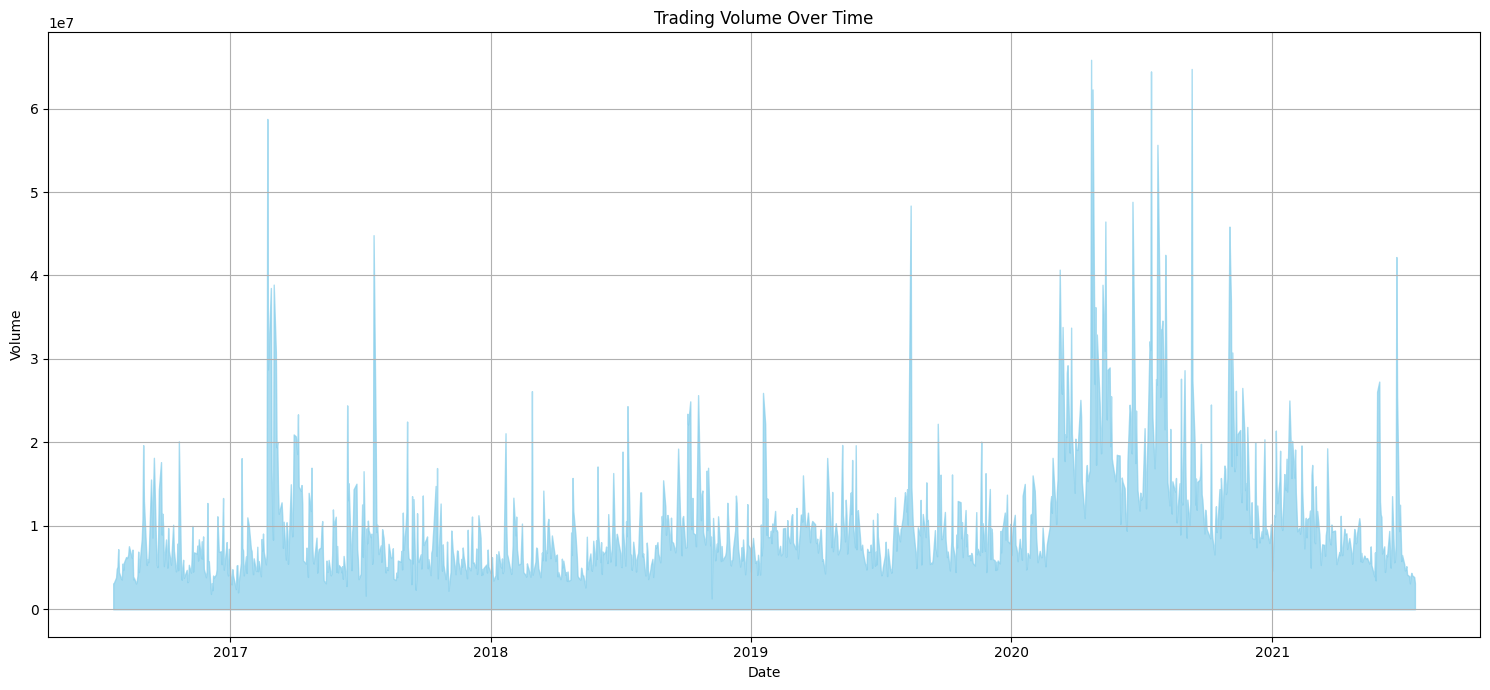

In [ ]:
plt.figure(figsize=(15, 7))
plt.fill_between(df.index, df['Volume'], color='skyblue', alpha=0.7)
plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.tight_layout()
plt.show()

### Insight 4: Average Monthly Closing Price Distribution

**Description:** This insight shows the average closing price of the stock for each month across all years in the dataset, providing a seasonal perspective.

**Why this graph (Donut Chart)?** A donut chart is excellent for displaying the proportional contribution of different categories to a whole. In this case, it visually represents how the average closing price is distributed across the 12 months, highlighting which months tend to have higher or lower averages relative to each other. It's a variation of a pie chart, offering a central area for additional information or just a cleaner look.

**Purpose:** To identify potential seasonal patterns in the stock's average performance. This can help in understanding if certain months are historically stronger or weaker for the stock.

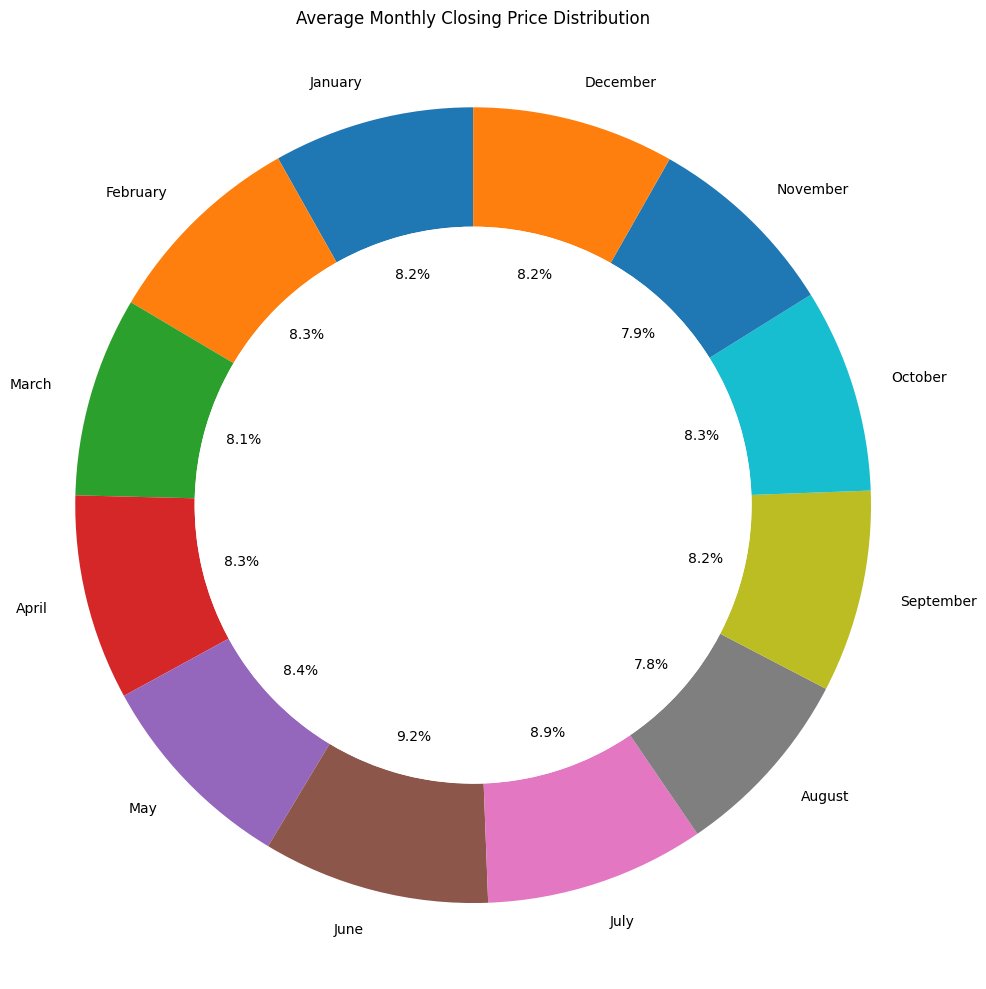

In [ ]:
monthly_avg_close = df.groupby('Month')['Close'].mean().reindex(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])

plt.figure(figsize=(10, 10))
plt.pie(monthly_avg_close, labels=monthly_avg_close.index, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Average Monthly Closing Price Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Insight 5: Year-over-Year (YoY) Change in Average Close Price

**Description:** This insight calculates the percentage change in the average closing price from one year to the next, illustrating the annual growth or decline.

**Why this graph (Lollipop Chart)?** A lollipop chart is a stylistic variation of a bar chart, often preferred for its clean visual presentation, especially when comparing discrete values. It's effective here because it clearly shows the magnitude of the YoY change for each year with a distinct point, making it easy to compare annual performance. The stem extending from the baseline helps in judging positive versus negative changes.

**Purpose:** To quickly assess the annual growth rate of the stock, identify years of strong growth or contraction, and understand the consistency of its long-term performance.

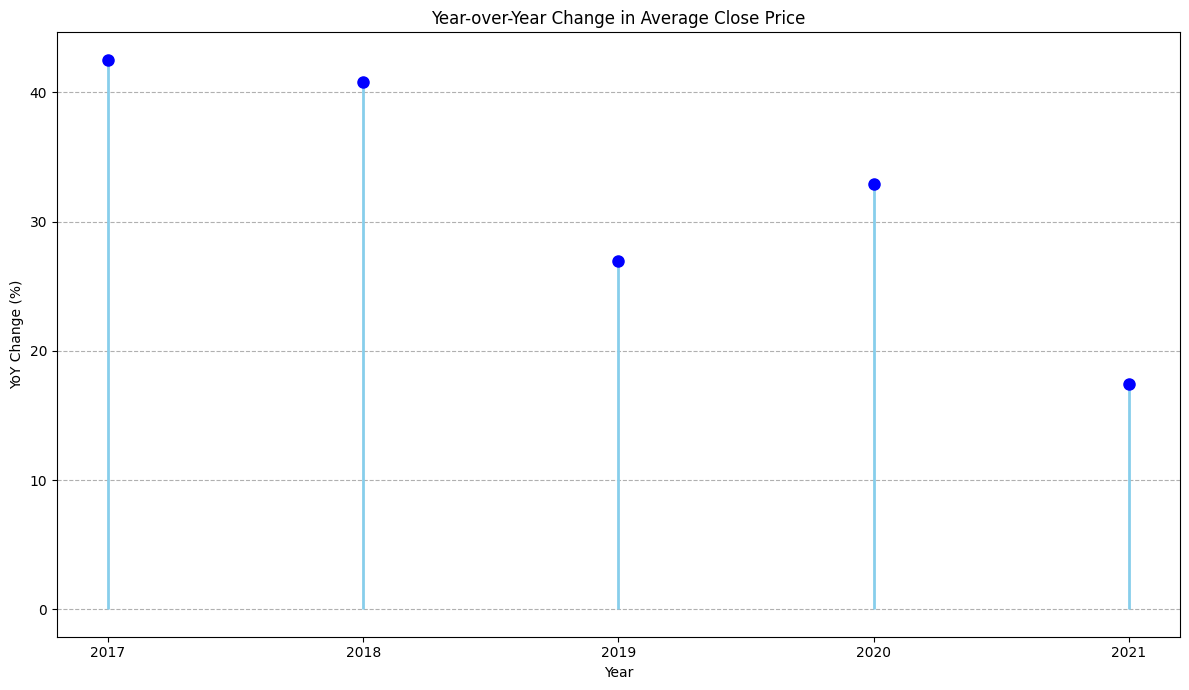

In [ ]:
yearly_avg = df.groupby('Year')['Close'].mean()
yoy_change = yearly_avg.pct_change() * 100
yoy_df = pd.DataFrame({'Year': yoy_change.index, 'YoY Change (%)': yoy_change.values}).dropna()

plt.figure(figsize=(12, 7))
plt.vlines(x=yoy_df['Year'], ymin=0, ymax=yoy_df['YoY Change (%)'], color='skyblue', linestyle='-', lw=2)
plt.plot(yoy_df['Year'], yoy_df['YoY Change (%)'], "o", color='blue', markersize=8)

plt.title('Year-over-Year Change in Average Close Price')
plt.xlabel('Year')
plt.ylabel('YoY Change (%)')
plt.xticks(yoy_df['Year'])
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### Insight 6: Volatility Over Time

**Description:** This insight tracks the rolling 30-day standard deviation of daily returns, representing the stock's price fluctuation over short periods.

**Why this graph (Line Plot)?** A line plot is ideal for showing how volatility, a continuous metric, changes over time. It allows for easy identification of periods where the stock was more or less volatile.

**Purpose:** To understand the periods of higher or lower risk associated with the stock. Traders and investors use volatility to gauge potential price swings and manage risk.

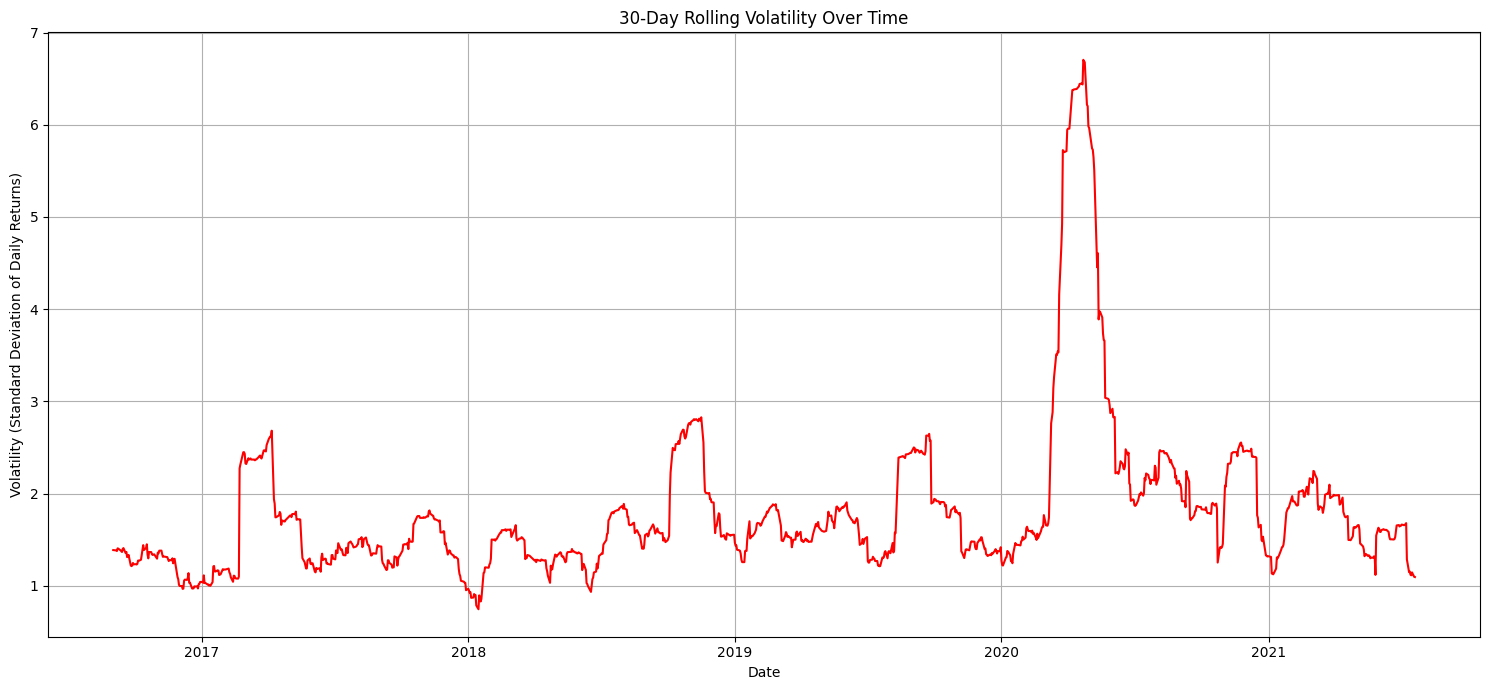

In [ ]:
plt.figure(figsize=(15, 7))
# Create a temporary DataFrame for plotting to ensure index and data length match
plot_df = df.dropna(subset=['Volatility'])
sns.lineplot(x=plot_df.index, y='Volatility', data=plot_df, color='red')
plt.title('30-Day Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation of Daily Returns)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Insight 7: Distribution of Daily Returns

**Description:** This insight shows the frequency of different daily percentage returns, helping to understand the typical performance and extreme events.

**Why this graph (Distribution Plot / Histogram with KDE)?** A distribution plot (specifically `seaborn.histplot` with `kde=True`) is excellent for visualizing the shape of a single numerical variable's distribution. It combines a histogram to show frequency bins and a Kernel Density Estimate (KDE) curve to smooth out the distribution, offering a clearer picture of central tendency, spread, and skewness of daily returns.

**Purpose:** To understand the probability of various daily returns. A narrow, high peak indicates stable returns, while a wider, flatter distribution suggests more frequent large swings. It helps in assessing the risk and reward characteristics of the stock.

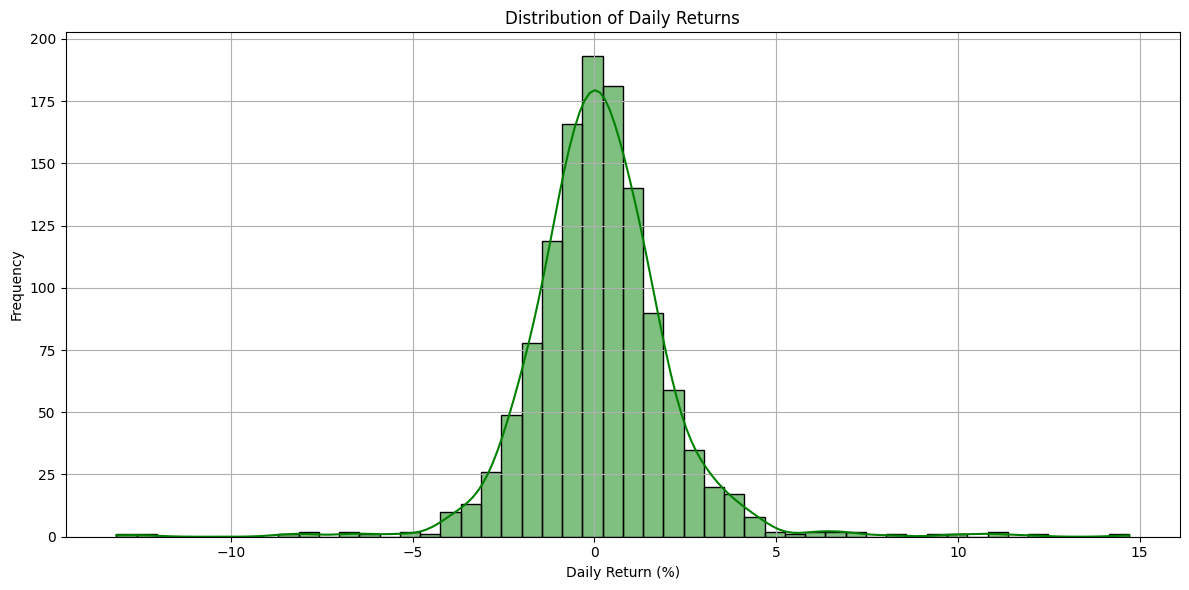

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Daily Return'].dropna(), bins=50, kde=True, color='green')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

### Insight 8: Intraday Change Distribution by Year

**Description:** This insight displays the distribution of intraday price changes (Close - Open) for each year, allowing for a comparison of yearly intraday volatility and direction.

**Why this graph (Violin Plot)?** A violin plot is superior to a simple box plot for showing the *distribution shape* within categories. It combines a box plot's summary statistics (median, quartiles) with a kernel density estimate to show the full distribution of the data. This is useful here to compare how the typical intraday price changes and their spread vary across different years.

**Purpose:** To identify if the pattern of daily price movements has changed significantly from year to year, indicating shifts in market behavior or stock characteristics.

/tmp/ipykernel_6220/1922814793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Year', y='Intraday Change', data=df, palette='viridis')


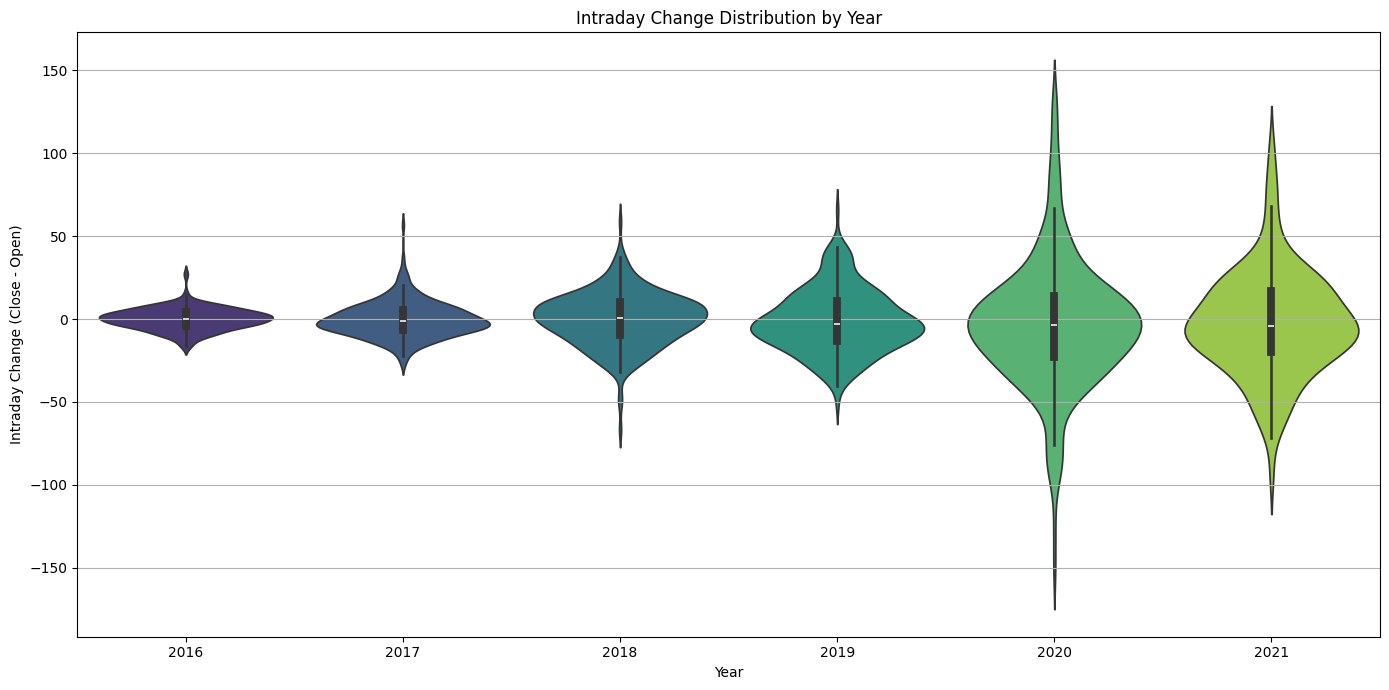

In [ ]:
plt.figure(figsize=(14, 7))
sns.violinplot(x='Year', y='Intraday Change', data=df, palette='viridis')
plt.title('Intraday Change Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Intraday Change (Close - Open)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Insight 9: Daily Trading Range Distribution by Year

**Description:** This insight illustrates the distribution of the daily high-low price range for each year, providing a view into how the extent of daily price movement has evolved.

**Why this graph (Boxen Plot)?** A boxen plot (also known as a letter-value plot) is an enhanced version of a box plot, designed to show more quantiles. It is particularly useful for larger datasets as it provides a more detailed representation of the distribution's tails and central tendencies compared to a standard box plot. Comparing these across years helps in discerning subtle changes in daily price range patterns.

**Purpose:** To assess how the typical magnitude of daily price fluctuations (volatility within a day) has varied annually. A larger range indicates more active trading and price discovery within the day, while a smaller range suggests relative stability.

/tmp/ipykernel_6220/3940887803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Year', y='Daily Range', data=df, palette='magma')


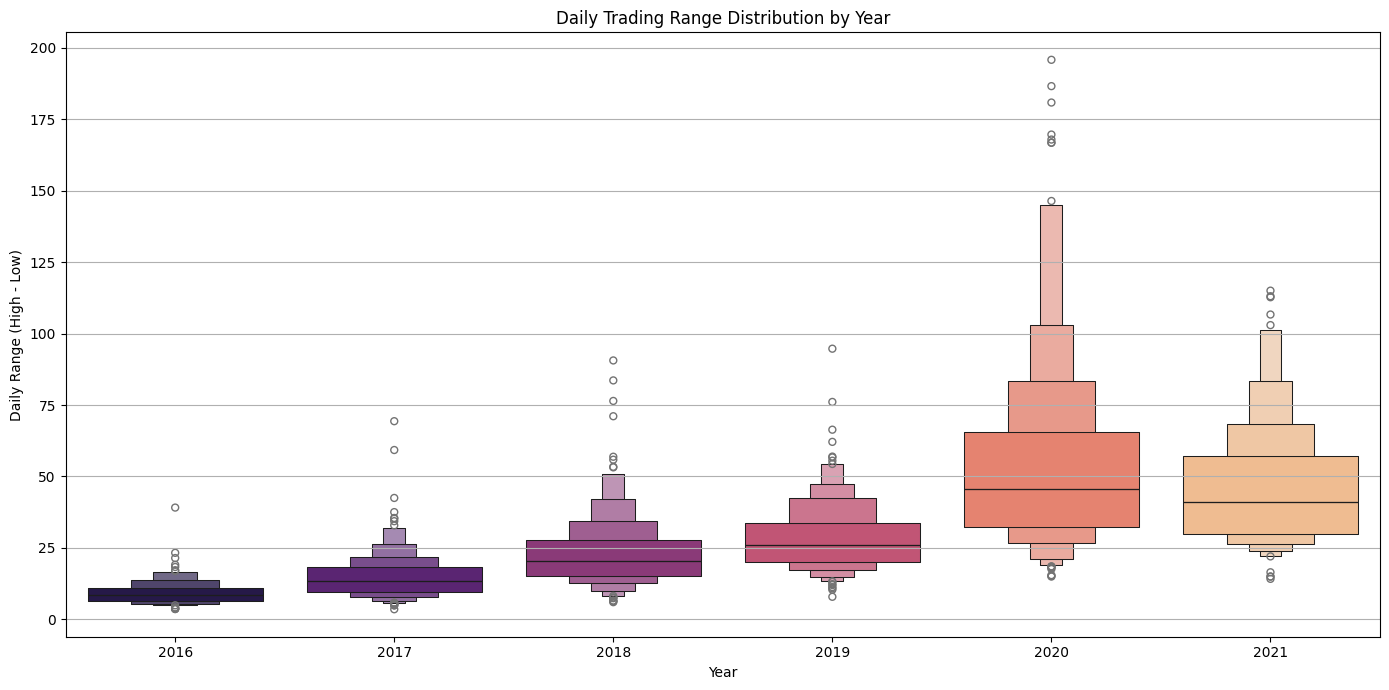

In [ ]:
plt.figure(figsize=(14, 7))
sns.boxenplot(x='Year', y='Daily Range', data=df, palette='magma')
plt.title('Daily Trading Range Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Daily Range (High - Low)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Insight 10: Moving Averages and Close Price Comparison

**Description:** This insight compares the stock's closing price with its 50-day Simple Moving Average (SMA_50) and 200-day Simple Moving Average (SMA_200). Moving averages are widely used technical indicators to smooth out price data and identify trends.

**Why this graph (Multi-line Plot)?** A multi-line plot is essential here because it allows for the simultaneous visualization of multiple time-series datasets (Close Price, SMA_50, SMA_200) on the same axes. This enables direct comparison and identification of crossovers, which are important signals in technical analysis.

**Purpose:** To identify trends and potential buy/sell signals. When the short-term average (SMA_50) crosses above the long-term average (SMA_200), it's often considered a bullish signal (Golden Cross), and vice-versa for a bearish signal (Death Cross). It helps in understanding the underlying momentum of the stock.

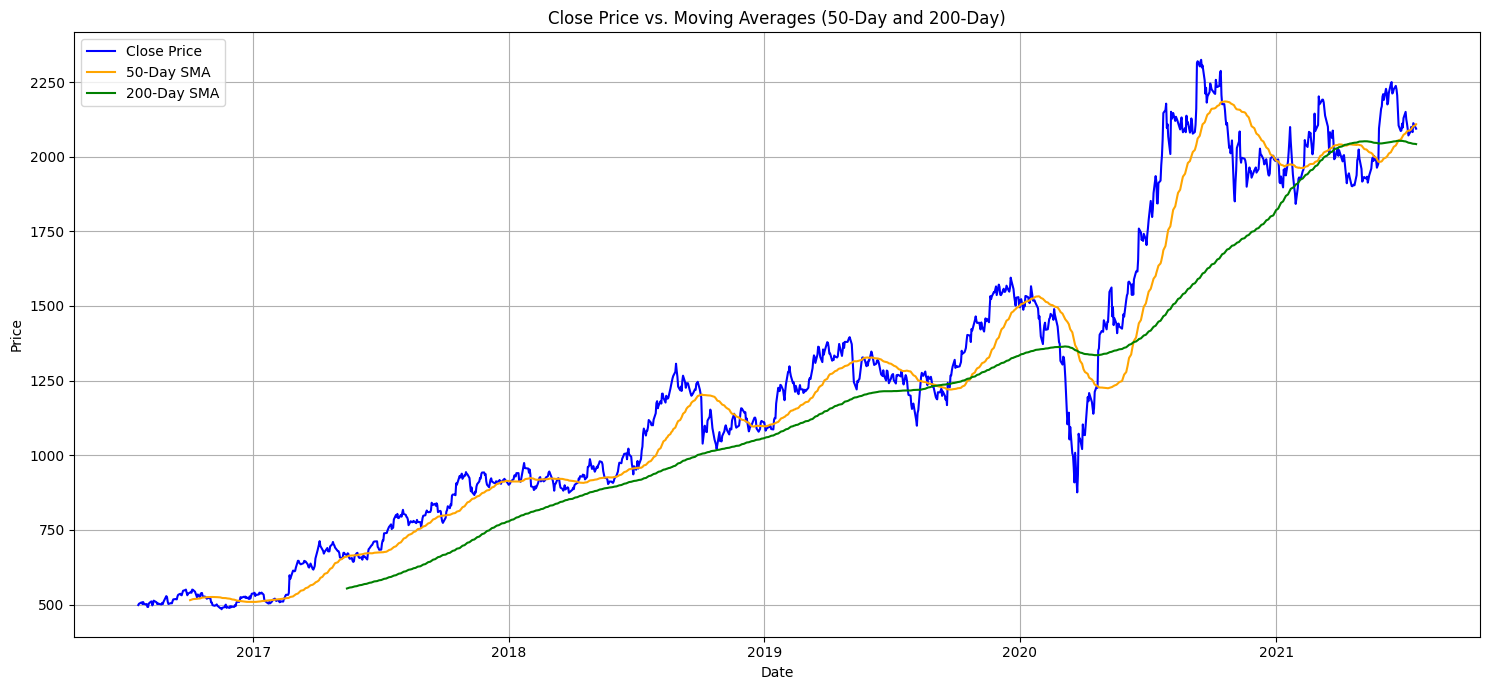

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(x=df.index, y='Close', data=df, label='Close Price', color='blue')
sns.lineplot(x=df.index, y='SMA_50', data=df, label='50-Day SMA', color='orange')
sns.lineplot(x=df.index, y='SMA_200', data=df, label='200-Day SMA', color='green')
plt.title('Close Price vs. Moving Averages (50-Day and 200-Day)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()